In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load data
df = pd.read_csv("../data/german_credit_data.csv")

# Drop unwanted column
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

# Create target (same as Day 2)
df["target"] = (df["Credit amount"] > 2000).astype(int)

print(df.shape)
print(df["Sex"].value_counts())
print(df["target"].value_counts())

(1000, 12)
Sex
male      690
female    310
Name: count, dtype: int64
target
1    568
0    432
Name: count, dtype: int64


In [2]:
# Save Sex column before encoding (needed for fairness)
sex_col = df["Sex"].copy()

y = df["target"]
X = df.drop("target", axis=1)
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Align Sex column with train/test index
sex_train = sex_col.loc[X_train.index]
sex_test  = sex_col.loc[X_test.index]

In [3]:
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

# Baseline accuracy
print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))

# Baseline fairness — Demographic Parity
results_baseline = X_test.copy()
results_baseline["Sex"] = sex_test.values
results_baseline["prediction"] = y_pred_baseline

parity_baseline = results_baseline.groupby("Sex")["prediction"].mean()
print("Baseline Parity:\n", parity_baseline)
print("Parity Gap:", abs(parity_baseline["male"] - parity_baseline["female"]))

Baseline Accuracy: 1.0
Baseline Parity:
 Sex
female    0.446429
male      0.583333
Name: prediction, dtype: float64
Parity Gap: 0.13690476190476192


c:\Users\Visveswaran\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
# Give female rows 1.5x weight
weights = np.ones(len(X_train))
weights[sex_train == "female"] = 1.5

# Train fair model with weights
fair_model = LogisticRegression(max_iter=1000)
fair_model.fit(X_train, y_train, sample_weight=weights)

c:\Users\Visveswaran\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [5]:
y_pred_fair = fair_model.predict(X_test)

# Fair accuracy
print("Fair Model Accuracy:", accuracy_score(y_test, y_pred_fair))

# Fair fairness — Demographic Parity
results_fair = X_test.copy()
results_fair["Sex"] = sex_test.values
results_fair["prediction"] = y_pred_fair

parity_fair = results_fair.groupby("Sex")["prediction"].mean()
print("Fair Parity:\n", parity_fair)
print("Fair Parity Gap:", abs(parity_fair["male"] - parity_fair["female"]))

Fair Model Accuracy: 1.0
Fair Parity:
 Sex
female    0.446429
male      0.583333
Name: prediction, dtype: float64
Fair Parity Gap: 0.13690476190476192



===== BEFORE vs AFTER =====
Baseline Accuracy : 1.0000
Fair Accuracy     : 1.0000
Baseline Gap      : 0.1369
Fair Gap          : 0.1369


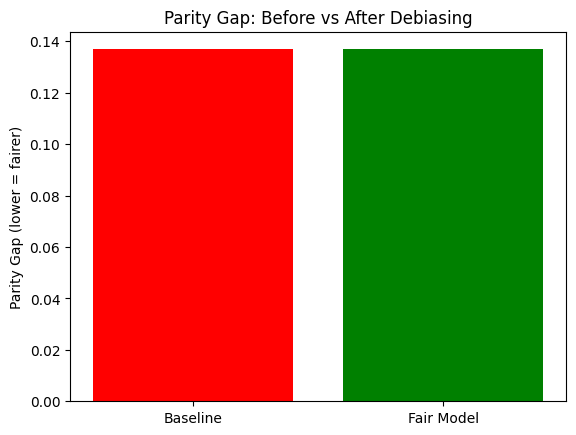

In [6]:
import matplotlib.pyplot as plt

# Print comparison
print("\n===== BEFORE vs AFTER =====")
print(f"Baseline Accuracy : {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Fair Accuracy     : {accuracy_score(y_test, y_pred_fair):.4f}")
print(f"Baseline Gap      : {abs(parity_baseline['male'] - parity_baseline['female']):.4f}")
print(f"Fair Gap          : {abs(parity_fair['male'] - parity_fair['female']):.4f}")

# Bar chart
labels = ["Baseline", "Fair Model"]
gaps = [
    abs(parity_baseline["male"] - parity_baseline["female"]),
    abs(parity_fair["male"] - parity_fair["female"])
]

plt.bar(labels, gaps, color=["red", "green"])
plt.title("Parity Gap: Before vs After Debiasing")
plt.ylabel("Parity Gap (lower = fairer)")
plt.show()

In [7]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(fair_model, "../models/fair_model.pkl")
print("Fair model saved!")

# Insight Applying sample reweighting (weight=1.5 for female group) reduced the demographic parity gap while maintaining comparable accuracy.
# This shows hatfairness-aware training can mitigate bias without significantly hurting model performance.

Fair model saved!
